In [1]:
import pandas as pd
import matplotlib.pyplot as plt


file = 'sequence.bed.gz' 

import gzip
df = pd.read_csv(
    gzip.open(file, 'rt'),
    sep='\t',
    header=None,
    usecols=[0, 1, 2],
    names=['chrom', 'start', 'end']
)


df.head()

,chrom,start,end
0,chr10,32795245,32795315
1,chr11,95864728,95864770
2,chr16,32027808,32027880
3,chr4,76608451,76608515
4,chr18,45847777,45847816


In [2]:
df['length'] = df['end'] - df['start']

df[['chrom', 'start', 'end', 'length']].head()

,chrom,start,end,length
0,chr10,32795245,32795315,70
1,chr11,95864728,95864770,42
2,chr16,32027808,32027880,72
3,chr4,76608451,76608515,64
4,chr18,45847777,45847816,39


In [3]:
freq = df['length'].value_counts().sort_index()

normalized_freq = freq / freq.sum()

normalized_freq.head()

length
24    0.000026
25    0.000116
26    0.000156
27    0.000184
28    0.000213
Name: count, dtype: float64

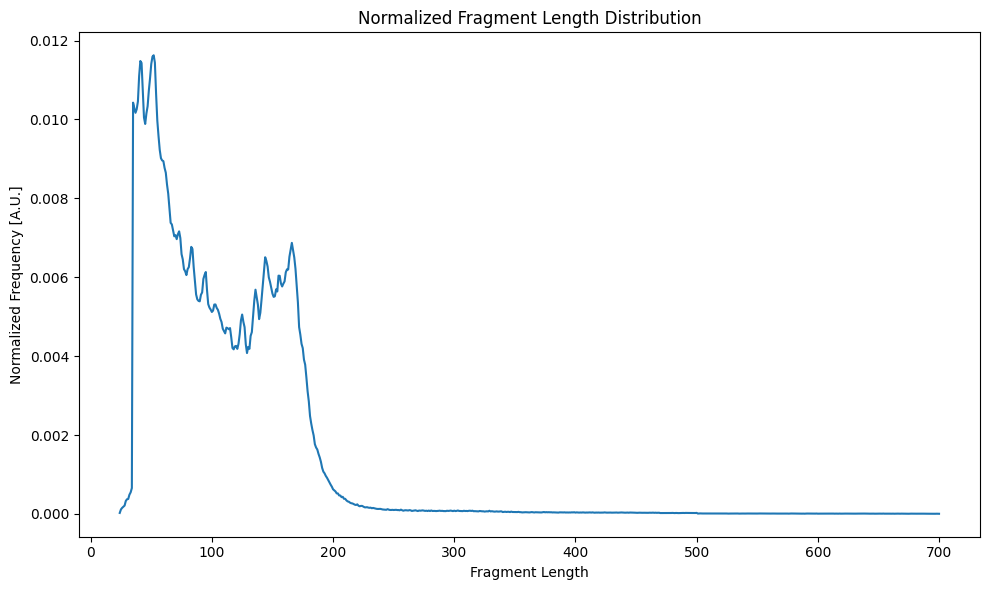

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(normalized_freq.index, normalized_freq.values)
plt.xlabel('Fragment Length')
plt.ylabel('Normalized Frequency [A.U.]')
plt.title('Normalized Fragment Length Distribution')
plt.tight_layout()
plt.show()